## First

In [ ]:
!pip install img2dataset datasets

In [ ]:
import os
from datasets import load_dataset
import csv

BASE_DIR = "/home/rahul/shyam/aditya/training/cc3m"
SHARDS_DIR = f"{BASE_DIR}/shards"
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(SHARDS_DIR, exist_ok=True)

print("Loading CC3M metadata...")
cc3m_meta = load_dataset(
    "google-research-datasets/conceptual_captions",
    split="train",
    trust_remote_code=True
)
print(f"Total samples: {len(cc3m_meta)}")
print(f"Sample: {cc3m_meta[0]}")

In [ ]:
url_file = f"{BASE_DIR}/cc3m_urls.tsv"

print(f"Writing URLs to {url_file}...")
with open(url_file, 'w', newline='') as f:
    writer = csv.writer(f, delimiter='\t')
    writer.writerow(['url', 'caption'])
    for sample in cc3m_meta:
        writer.writerow([sample['image_url'], sample['caption']])
print(f"Done: {len(cc3m_meta)} rows written")

In [ ]:
!img2dataset \
    --url_list "/home/rahul/shyam/aditya/training/cc3m/cc3m_urls.tsv" \
    --input_format tsv \
    --url_col url \
    --caption_col caption \
    --output_format webdataset \
    --output_folder "/home/rahul/shyam/aditya/training/cc3m/shards" \
    --processes_count 8 \
    --thread_count 64 \
    --image_size 336 \
    --resize_mode keep_ratio \
    --min_image_size 100 \
    --max_aspect_ratio 3.0 \
    --number_sample_per_shard 5000 \
    --retries 2 \
    --enable_wandb False

In [ ]:
import glob, os

shards = sorted(glob.glob("/home/rahul/shyam/aditya/training/cc3m/shards/*.tar"))
total_size = sum(os.path.getsize(f) for f in shards) / 1e9

print(f"Shards downloaded : {len(shards)}")
print(f"Disk used         : {total_size:.1f} GB")
print(f"Estimated images  : ~{len(shards) * 5000 * 0.55:,.0f}")

In [ ]:
from transformers import AutoModel, AutoTokenizer
from peft import get_peft_model, LoraConfig, TaskType

model = AutoModel.from_pretrained(
    "Qwen/Qwen3-Embedding-0.6B",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-Embedding-0.6B",
    trust_remote_code=True
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=8,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type=TaskType.FEATURE_EXTRACTION,
)

peft_model = get_peft_model(model, lora_config)

print("LoRA attached successfully")

In [ ]:
from transformers import AutoModel, AutoTokenizer
import torch

model = AutoModel.from_pretrained(
    "Qwen/Qwen3-Embedding-0.6B",
    trust_remote_code=True
).cuda()

tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-Embedding-0.6B",
    trust_remote_code=True
)

inputs = tokenizer(
    ["a dog running in a park"],
    return_tensors="pt",
    padding=True,
    truncation=True,
).to("cuda")

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.last_hidden_state.shape)

In [ ]:
!pip install -U torch transformers peft accelerate sentencepiece safetensors

In [ ]:
import torch
import transformers
import peft

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)

In [ ]:
import sys
print(sys.executable)

import huggingface_hub
print(huggingface_hub.__version__)
print(huggingface_hub.__file__)

In [ ]:
import sys
sys.path = [p for p in sys.path if ".local/lib/python3.10/site-packages" not in p]

import huggingface_hub
print(huggingface_hub.__version__)
print(huggingface_hub.__file__)

## Second

In [ ]:
from transformers import CLIPModel
import torch
m = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    out = m.vision_model(pixel_values=dummy)
    proj = m.visual_projection(out.pooler_output)
print(proj.shape)  # confirm this before setting embed_dim

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained('Salesforce/SFR-Embedding-2_R')
model = AutoModel.from_pretrained(
    'Salesforce/SFR-Embedding-2_R',
    torch_dtype=torch.bfloat16
).cuda()

inputs = tokenizer(
    ["a dog running in a park"],
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256
).to("cuda")

with torch.no_grad():
    outputs = model(**inputs)

print("hidden state shape:", outputs.last_hidden_state.shape)
# Expect: [1, seq_len, 4096]
print("dtype:", outputs.last_hidden_state.dtype)
# Expect: torch.bfloat16

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=64,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION,
)
peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()
# Expect: trainable params << 7B, ~1-2% of total
print("LoRA attached OK")

In [ ]:
from transformers import CLIPModel
import torch

clip = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").cuda()
dummy = torch.randn(1, 3, 224, 224).cuda()

with torch.no_grad():
    out = clip.vision_model(pixel_values=dummy)
    proj = clip.visual_projection(out.pooler_output)

print("CLIP-L/14 visual_projection output:", proj.shape)
# This tells us embed_dim — likely 768
print("CLIP vision pooler_output (pre-proj):", out.pooler_output.shape)
# This tells us clip_dim going into adapter — likely 1024

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Based on Cell 3 results — fill in after running
CLIP_POOLER_DIM = 1024   # out.pooler_output shape[-1]
CLIP_PROJ_DIM   = 768    # proj shape[-1]  → this is embed_dim
LLM_DIM         = 4096   # SFR hidden dim

# Adapter: CLIP pooler → LLM token space
adapter = nn.Sequential(
    nn.Linear(CLIP_POOLER_DIM, LLM_DIM),
    nn.GELU(),
    nn.Linear(LLM_DIM, LLM_DIM),
).cuda().to(torch.bfloat16)

# Projection: LLM hidden → retrieval space (must match z dim)
projection = nn.Linear(LLM_DIM, CLIP_PROJ_DIM).cuda().to(torch.bfloat16)

dummy_clip = torch.randn(2, CLIP_POOLER_DIM).cuda().to(torch.bfloat16)
dummy_llm  = torch.randn(2, LLM_DIM).cuda().to(torch.bfloat16)

adapted = adapter(dummy_clip)
print("adapter output:", adapted.shape)   # [2, 4096] ✓

proj_out = F.normalize(projection(dummy_llm), dim=-1)
print("projection output:", proj_out.shape)  # [2, 768] ✓

# Contrastive loss dot product check
z = torch.randn(2, CLIP_PROJ_DIM).cuda().float()
c = proj_out.float()
logits = c @ z.T
print("logits shape:", logits.shape)  # [2, 2] ✓ — square matrix needed for loss

## Dataset Verif

In [1]:
from pathlib import Path
import sys
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path.cwd()
CODE_DIR = REPO_ROOT / "Code_Files"
sys.path.insert(0, str(CODE_DIR))

MANIFEST = Path(
    "/home/rahul/shyam/aditya/training/mtcir_stage2/"
    "mtcir_600k_chunk2.jsonl"
)
IMAGE_ROOT = Path(
    "/home/rahul/shyam/aditya/training/llava_images_chunk2"
)

print("Repository:", REPO_ROOT)
print("Manifest exists:", MANIFEST.exists(), MANIFEST)
print("Image root exists:", IMAGE_ROOT.exists(), IMAGE_ROOT)

Repository: /home/rahul/shyam/aditya/CoLLM_Implementation
Manifest exists: True /home/rahul/shyam/aditya/training/mtcir_stage2/mtcir_600k_chunk2.jsonl
Image root exists: True /home/rahul/shyam/aditya/training/llava_images_chunk2


In [2]:
raw_rows = []

with MANIFEST.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            raw_rows.append(json.loads(line))

print(f"Raw image-pair records: {len(raw_rows):,}")

for i, row in enumerate(raw_rows[:3]):
    print(f"\n--- Raw record {i} ---")
    print(json.dumps(row, indent=2, ensure_ascii=False))

Raw image-pair records: 100,000

--- Raw record 0 ---
{
  "id": "000750224f",
  "image": "00543/005438062.jpg",
  "target_image": "00408/004083757.jpg",
  "modifications": [
    "Remove the peace sign pendants.",
    "Add hair clips with bows.",
    "Increase number to sixteen.",
    "Change material to plastic.",
    "Add various bow colors.",
    "Change from jewelry to hair accessories.",
    "Change to grid layout."
  ]
}

--- Raw record 1 ---
{
  "id": "001637407b",
  "image": "00411/004112073.jpg",
  "target_image": "00190/001901830.jpg",
  "modifications": [
    "Remove the man on horseback.",
    "Exclude the cattle.",
    "Remove the herding dog.",
    "Change landscape to rocky.",
    "Modify sky to fiery.",
    "Change horses to wandering.",
    "Switch to surreal style."
  ]
}

--- Raw record 2 ---
{
  "id": "000195047f",
  "image": "00318/003185030.jpg",
  "target_image": "00049/000499851.jpg",
  "modifications": [
    "Remove the wooden pole with knob.",
    "Remove the A

In [3]:
required_keys = {"image", "target_image"}

invalid_rows = []
modification_counts = []

for i, row in enumerate(raw_rows):
    missing = required_keys - set(row)
    modifications = row.get("modifications", [])

    if missing or not isinstance(modifications, list):
        invalid_rows.append((i, missing, type(modifications).__name__))

    modification_counts.append(len(modifications))

modification_counts = np.asarray(modification_counts)

print("Invalid rows:", len(invalid_rows))
print("Image pairs:", len(raw_rows))
print("Expanded triplets expected:", np.maximum(modification_counts, 1).sum())
print("Mean modifications/pair:", modification_counts.mean())
print("Median modifications/pair:", np.median(modification_counts))
print("Minimum:", modification_counts.min())
print("Maximum:", modification_counts.max())
print("Pairs with no modifications:", (modification_counts == 0).sum())

if invalid_rows:
    print("First invalid rows:", invalid_rows[:10])

Invalid rows: 0
Image pairs: 100000
Expanded triplets expected: 517978
Mean modifications/pair: 5.17978
Median modifications/pair: 5.0
Minimum: 1
Maximum: 28
Pairs with no modifications: 0


In [4]:
from dataset_stage2 import CIRTripletDataset

dataset = CIRTripletDataset(
    manifest_path=str(MANIFEST),
    image_root=str(IMAGE_ROOT),
)

print(f"Expanded dataset length: {len(dataset):,}")
print("\nFirst expanded row:")
print(json.dumps(dataset.rows[0], indent=2, ensure_ascii=False))

Loaded 517,978 expanded triplets from /home/rahul/shyam/aditya/training/mtcir_stage2/mtcir_600k_chunk2.jsonl
Expanded dataset length: 517,978

First expanded row:
{
  "image": "00543/005438062.jpg",
  "target_image": "00408/004083757.jpg",
  "mod_text": "Remove the peace sign pendants."
}


In [5]:
from dataset_stage2 import CIRTripletDataset

dataset = CIRTripletDataset(
    manifest_path=str(MANIFEST),
    image_root=str(IMAGE_ROOT),
)

print(f"Expanded dataset length: {len(dataset):,}")
print("\nFirst expanded row:")
print(json.dumps(dataset.rows[0], indent=2, ensure_ascii=False))

Loaded 517,978 expanded triplets from /home/rahul/shyam/aditya/training/mtcir_stage2/mtcir_600k_chunk2.jsonl
Expanded dataset length: 517,978

First expanded row:
{
  "image": "00543/005438062.jpg",
  "target_image": "00408/004083757.jpg",
  "mod_text": "Remove the peace sign pendants."
}


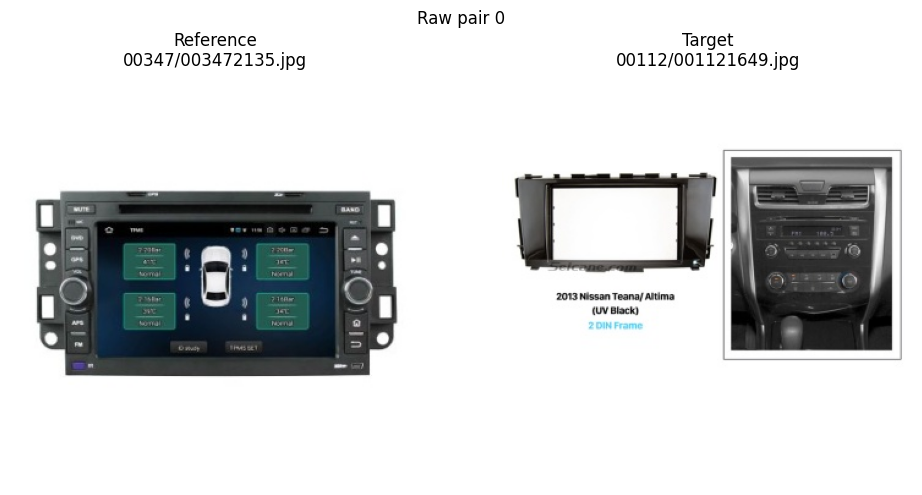

Modifications:
  1. Change viewpoint to radio frame
  2. Add radio frame template
  3. Remove touchscreen display
  4. Remove navigation menu icons
  5. Remove car graphic interface
  6. Remove driving assistance menu
  7. Change interface style to informative
----------------------------------------------------------------------------------------------------


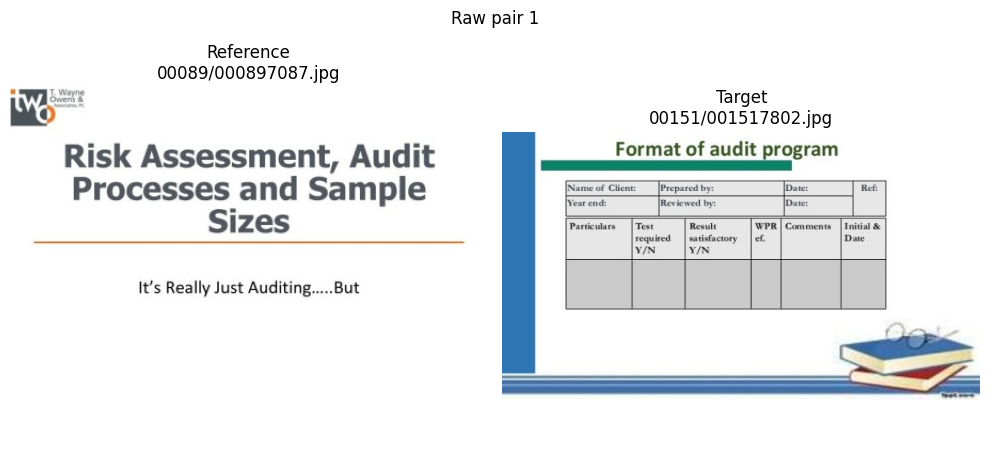

Modifications:
  1. Add table with columns.
  2. Include book graphic.
  3. Change background color.
  4. Modify title text.
----------------------------------------------------------------------------------------------------


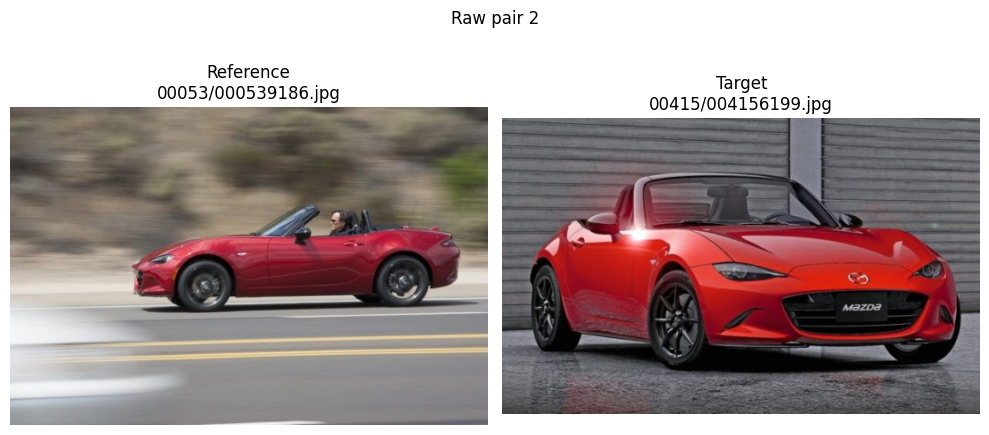

Modifications:
  1. Add a concrete floor
  2. Add a gray wall
  3. Remove the blurred background
  4. Remove the hill/mountain
  5. Remove the double yellow line
  6. Add Mazda car brand
  7. Change viewpoint to side view
----------------------------------------------------------------------------------------------------


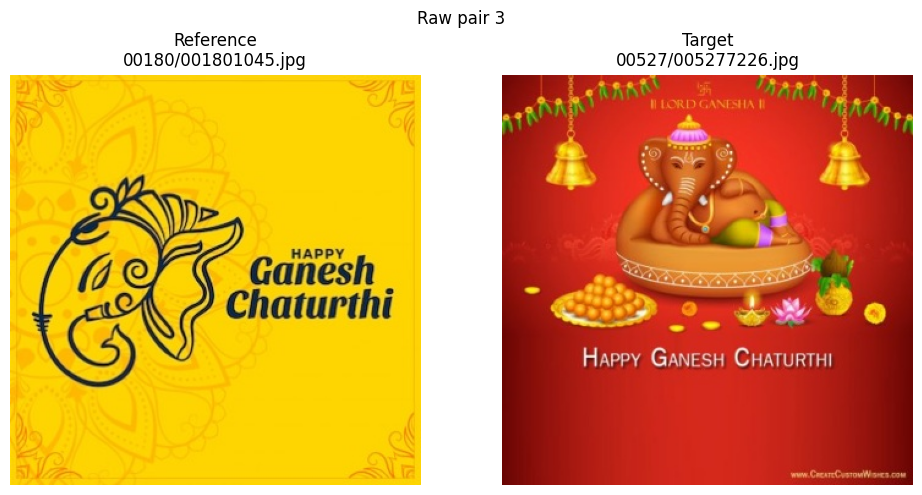

Modifications:
  1. Change to rich red background.
  2. Depict full Ganesha deity.
  3. Modify headdress to traditional crown.
  4. Add lotus flower seat.
  5. Include axe and sweets bowl.
  6. Add bells and figurines.
  7. Remove floral paisley patterns.
----------------------------------------------------------------------------------------------------


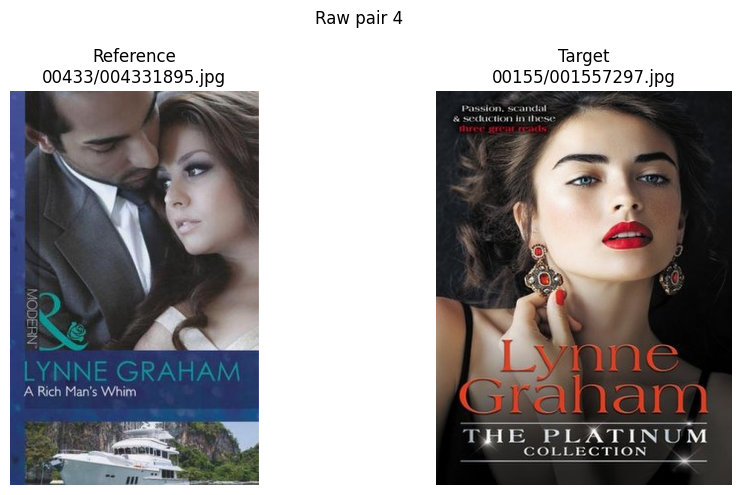

Modifications:
  1. Remove the intimate couple photo.
  2. Remove the yacht photo.
  3. Remove the book title.
  4. Add a close-up woman's face.
  5. Change background to gradient colors.
  6. Change text to 'Passion, scandal & seduction'.
----------------------------------------------------------------------------------------------------


In [6]:
def resolve_image(relative_path):
    path = IMAGE_ROOT / relative_path
    if not path.exists():
        raise FileNotFoundError(path)
    return path

random.seed(42)
selected_rows = random.sample(raw_rows, k=min(5, len(raw_rows)))

for index, row in enumerate(selected_rows):
    ref_path = resolve_image(row["image"])
    target_path = resolve_image(row["target_image"])

    ref_image = Image.open(ref_path).convert("RGB")
    target_image = Image.open(target_path).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(ref_image)
    axes[0].set_title(f"Reference\n{row['image']}")
    axes[0].axis("off")

    axes[1].imshow(target_image)
    axes[1].set_title(f"Target\n{row['target_image']}")
    axes[1].axis("off")

    plt.suptitle(f"Raw pair {index}")
    plt.tight_layout()
    plt.show()

    print("Modifications:")
    for j, text in enumerate(row.get("modifications", []), start=1):
        print(f"  {j}. {text}")

    print("-" * 100)

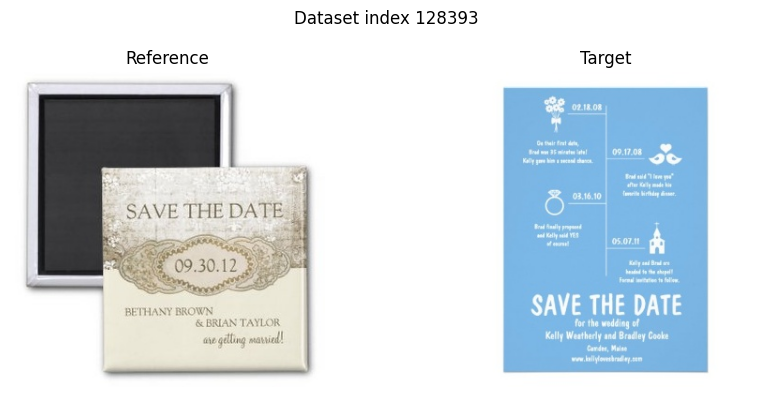

Reference: 00441/004416680.jpg
Target:    00119/001195266.jpg
Text:      Add wedding details, names, and dates.
----------------------------------------------------------------------------------------------------


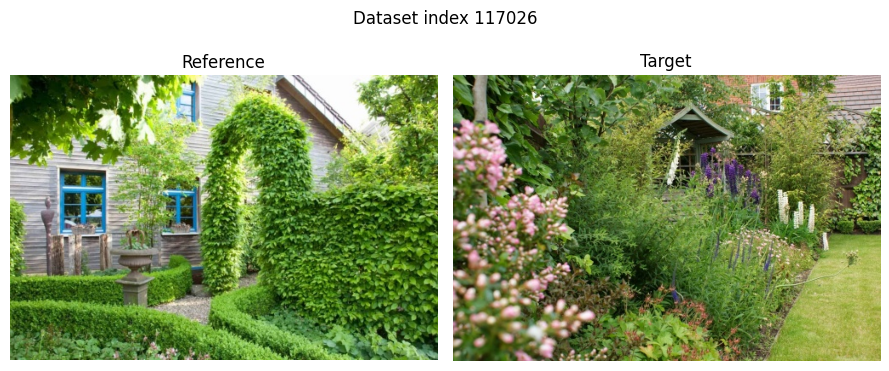

Reference: 00001/000016513.jpg
Target:    00180/001804730.jpg
Text:      Remove the building.
----------------------------------------------------------------------------------------------------


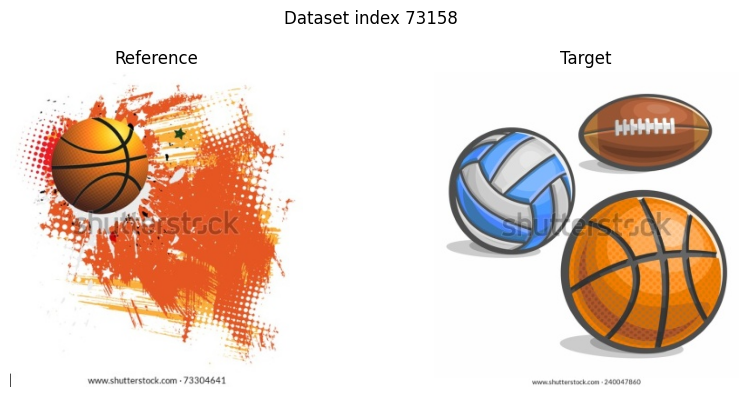

Reference: 00321/003215954.jpg
Target:    00011/000113044.jpg
Text:      Cartoon-like basketball style
----------------------------------------------------------------------------------------------------


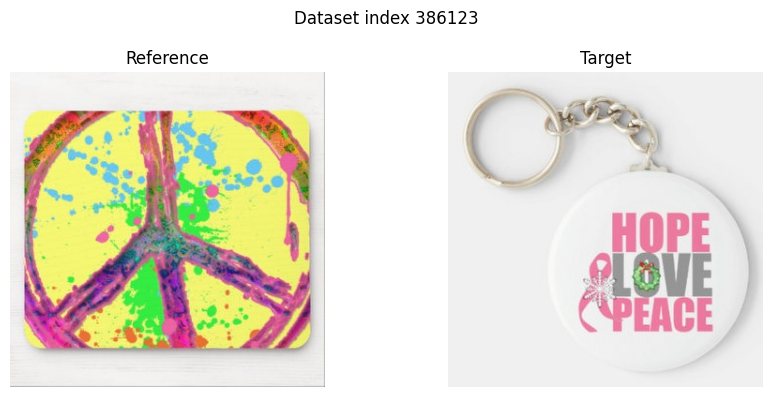

Reference: 00336/003361517.jpg
Target:    00323/003237706.jpg
Text:      Add a keychain with chain.
----------------------------------------------------------------------------------------------------


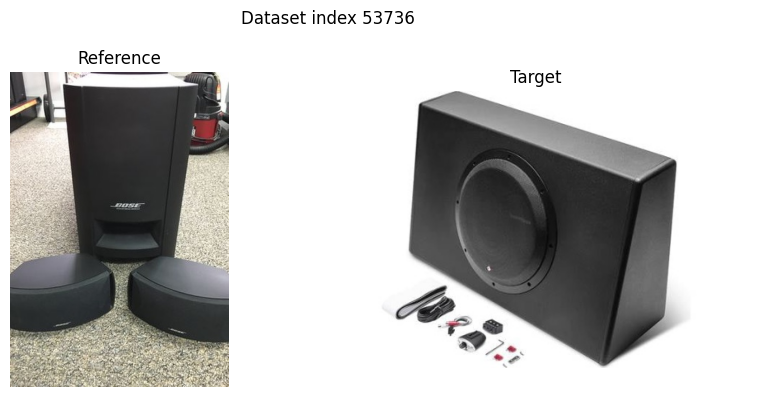

Reference: 00090/000903984.jpg
Target:    00077/000777891.jpg
Text:      Remove the satellite speakers.
----------------------------------------------------------------------------------------------------


In [7]:
indices = random.sample(range(len(dataset)), k=min(5, len(dataset)))

for idx in indices:
    row = dataset.rows[idx]

    ref_image = Image.open(resolve_image(row["image"])).convert("RGB")
    target_image = Image.open(resolve_image(row["target_image"])).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(ref_image)
    axes[0].set_title("Reference")
    axes[0].axis("off")

    axes[1].imshow(target_image)
    axes[1].set_title("Target")
    axes[1].axis("off")

    plt.suptitle(f"Dataset index {idx}")
    plt.tight_layout()
    plt.show()

    print("Reference:", row["image"])
    print("Target:   ", row["target_image"])
    print("Text:     ", row["mod_text"])
    print("-" * 100)

In [8]:
from dataset_stage2 import get_triplet_dataloader

loader = get_triplet_dataloader(
    manifest_path=str(MANIFEST),
    image_root=str(IMAGE_ROOT),
    batch_size=8,
    num_workers=0,  # safer inside Jupyter
    shuffle=True,
)

batch = next(iter(loader))

print("Reference tensor:", batch["ref_img"].shape)
print("Target tensor:   ", batch["target_img"].shape)
print("Number of texts: ", len(batch["mod_text"]))
print

Loaded 517,978 expanded triplets from /home/rahul/shyam/aditya/training/mtcir_stage2/mtcir_600k_chunk2.jsonl
Reference tensor: torch.Size([8, 3, 224, 224])
Target tensor:    torch.Size([8, 3, 224, 224])
Number of texts:  8


<function print>